# Install Libraries

In [1]:
!pip install gymnasium

In [2]:
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.4 MB/s eta 0:00:00


In [3]:
!pip install gymnasium[box2d]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for box2d-py: filename=box2d_py-2.3.5-cp312-cp312-linux_x86_64.whl size=2398778 sha256=39141a8fe85ed2eded2390df046e59acee6a3c35ebaa1128896bf6a96a14d058
  Stored in directory: /root/.cache/pip/wheels/2a/e9/60/774da0bcd07f7dc7761a8590fa2d065e4069568e78dcdc3318
Successfully built box2d-py


In [4]:
!pip install renderlab


In [5]:
!pip install 'stable-baselines3[extra]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 8.4 MB/s eta 0:00:00


# Import libraries

In [6]:
import renderlab
import numpy as np
from time import time
import renderlab as rl
import gymnasium as gym
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, DQN

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

  return datetime.utcnow().replace(tzinfo=utc)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintaine

# Question 2
Each gymnasium environment consists of 3 basic functions: step, reset, render. Then, describe the function of each one. You can consult the documentation https://www.gymlibrary.dev/content/basic_usage/

## Answer
Step: This is the agent action. It returns the next agent observation, the reward for taking that actions and also it has provides debug and metrices if environment terminated or truncated due to the latest action. It runs on timestep of the environment's dynamics using the agnt actions. It is an action provided by the agent to update the environment state.

Reset: It resets the environment to an initial state. When the end of an episode is reached it is important to call reset to reset the environment's stae for the next episode. When calling the reset function it returns an initial observation and info. This method generates a new starting state with some randomness to ensure that the agent explores the staate space.

Render: Renders the environments so we can see what agent see. This is happening by computing the render frames as specified by render_mode during the initialization of the environment.


# Question 3
Describe the LunarLander-v3 environment as follows:
1) Observation Space
2) Action Space
3) Reward Function

## Answer

The LunarLander-v3 is a part of the Box2D environments which containes information about the environment

![Lunar Lander Animation](https://gymnasium.farama.org/_images/lunar_lander.gif)

Starting with the observation state which is a state in an 8-dimensional vector. It consist of:
- coordinates of the lander in x, y
- linear velocities in x, y
- angle
- angular velocity
- two booleans representing whether each leg is in contact with the ground or not

Action space are the actions this rocket can make in the game. In this specific problem the rocket can do these actions:
- 0: do nothing
- 1: fire left orientation engine
- 2: fire main engine
- 3: fire right orientation engine

Reward function is used to give rewards to the agent. After each step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps in that episode. This reward can increase or decrease regarding the agent actions. If action is good then agent gets positive reward (means agents is closer to the goal or finish the game). If action is not ideal then agent gets negative reward. Below are all the differnt reward conditions:

- is increased/decreased the closer/further the lander is to the landing pad.
- is increased/decreased the slower/faster the lander is moving.
- is decreased the more the lander is tilted (angle not horizontal).
- is increased by 10 points for each leg that is in contact with the ground.
- is decreased by 0.03 points each frame a side engine is firing.
- is decreased by 0.3 points each frame the main engine is firing.

If agent crash then reward is -100 points and if it lands +100 points

# Question 4
Create a random agent and use the renderlab library to visualize its gameplay (as shown in the image below).

In [7]:
# Make env
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = rl.RenderFrame(env, './output')

# Reset the episode
observation, info = env.reset()

# run the model
while True :
  action = env.action_space.sample()
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break

env.play()

Moviepy - Building video temp-{start}.mp4.
Moviepy - Writing video temp-{start}.mp4



Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


# Question 5
Run the random agent for 5 episodes and then calculate the average score it achieves.

In [ ]:
# init variables
episodes = 5
scores = []

# run model for different episodes
for episode in range(episodes):
  observation, info = env.reset()
  sum_reward = 0
  while True :
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    sum_reward = sum_reward + reward

    if terminated or truncated:
      break

  # sum scores
  scores.append(sum_reward)

# print results
print(f"All scores: {scores}")
print(f"Average score: {sum(scores)/len(scores)}")


All scores: [np.float64(-294.3882371167535), np.float64(-130.45543070197823), np.float64(-320.19044621052865), np.float64(-108.02181568912147), np.float64(-191.28316808644155)]
Average score: -208.86781956096465


# Question 6
Use the Stable Baselines library to train the algorithms for a specific number of steps of your choice:
1. DQN
2. PPO

## DQN

In [ ]:
dqn_model = DQN("MlpPolicy", env, verbose=1)
dqn_model.learn(total_timesteps=10_000)

observation, info = env.reset()
while True :
  # action = env.action_space.sample()
  action, _states = dqn_model.predict(observation, deterministic=True)
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break

env.play()




Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 125      |
|    ep_rew_mean      | -344     |
|    exploration_rate | 0.526    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 210      |
|    time_elapsed     | 2        |
|    total_timesteps  | 499      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.93     |
|    n_updates        | 99       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 107      |
|    ep_rew_mean      | -334     |
|    exploration_rate | 0.19     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 205      |
|    time_elapsed     | 4        |
|    total_timesteps  | 853      |
| train/              |       

Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


## PPO

In [ ]:
ppo_model = PPO("MlpPolicy", env, verbose=1)
ppo_model.learn(total_timesteps=10_000)

observation, info = env.reset()
while True :
  # action = env.action_space.sample()
  action, _states = ppo_model.predict(observation, deterministic=True)
  observation, reward, terminated, truncated, info = env.step(action)

  if terminated or truncated:
    break


env.play()




  warnings.warn(



Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 96.1     |
|    ep_rew_mean     | -216     |
| time/              |          |
|    fps             | 162      |
|    iterations      | 1        |
|    time_elapsed    | 12       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 98.6         |
|    ep_rew_mean          | -209         |
| time/                   |              |
|    fps                  | 160          |
|    iterations           | 2            |
|    time_elapsed         | 25           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0050537414 |
|    clip_fraction        | 0.0119       |
|    clip_range           | 0.2          |
|    e

t:  90%|█████████ | 141/156 [00:00<00:00, 300.99it/s, now=None]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:123: UserWarning: Warning: in file ./output/1767947818.7313418.mp4, 720000 bytes wanted but 0 bytes read,at frame 155/156, at time 5.17/5.17 sec. Using the last valid frame instead.
  warnings.warn("Warning: in file %s, "%(self.filename)+

                                                               

Moviepy - Done !
Moviepy - video ready temp-{start}.mp4


# Question 7
Calculate the average reward over 5 episodes for each of the agents and create graphs comparing the algorithms on
1) Training time
2) Rewards per step/episode (during training)

### For DQN

All scores: [np.float64(-960.6587944519126), np.float64(-572.1020578600699), np.float64(-634.1577393924986), np.float64(-439.22841301449756), np.float64(-611.4509961227648)]
Average score: -643.5196001683487


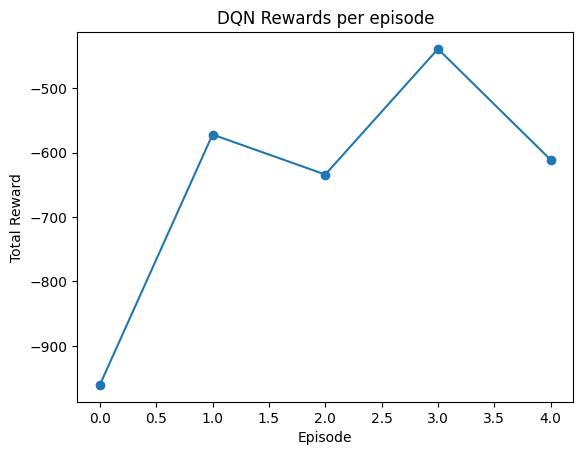

In [ ]:
dqn_model = DQN("MlpPolicy", env)

# Calculate model training time
start_time = time()
dqn_model.learn(total_timesteps=100)
dqn_training_time = time() - start_time

# init variables
episodes = 5
dqn_scores = []


for episode in range(episodes):
  observation, info = env.reset()
  sum_reward = 0
  while True :
    # action = env.action_space.sample()
    action, _states = dqn_model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)

    sum_reward = sum_reward + reward

    if terminated or truncated:
      break

  ## Debugg if results are correct
  # print("sum_reward: ",sum_reward)
  # env.play()

  # sum scores
  dqn_scores.append(sum_reward)

# print results
print(f"All scores: {dqn_scores}")
print(f"Average score: {sum(dqn_scores)/len(dqn_scores)}")


plt.plot(dqn_scores, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Rewards per episode")
plt.show()

# env.play()




### For PPO

  warnings.warn(



All scores: [np.float64(-556.7062736806577), np.float64(-507.9576247944341), np.float64(-117.92810397778521), np.float64(-173.65296784505563), np.float64(-857.0057174377408)]
Average score: -442.65013754713465


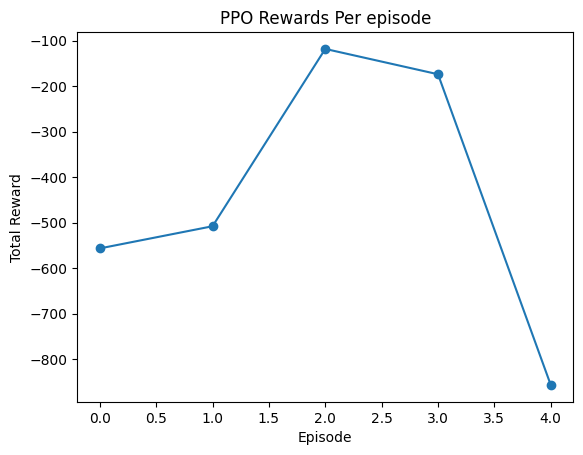

In [ ]:
ppo_model = PPO("MlpPolicy", env)

# Calculate model training time
start_time = time()
ppo_model.learn(total_timesteps=100)
ppo_training_time = time() - start_time

# init variables
episodes = 5
ppo_scores = []


for episode in range(episodes):
  observation, info = env.reset()
  sum_reward = 0
  while True :
    # action = env.action_space.sample()
    action, _states = ppo_model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)

    sum_reward = sum_reward + reward

    if terminated or truncated:
      break

  ## Debugg if results are correct
  # print("sum_reward: ",sum_reward)
  # env.play()

  # sum scores
  ppo_scores.append(sum_reward)

# print results
print(f"All scores: {ppo_scores}")
print(f"Average score: {sum(ppo_scores)/len(ppo_scores)}")


plt.plot(ppo_scores, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Rewards Per episode")
plt.show()

# env.play()




### Conclusion
By looking at the results PPO is getting way more time than DQN. The difference is very high.

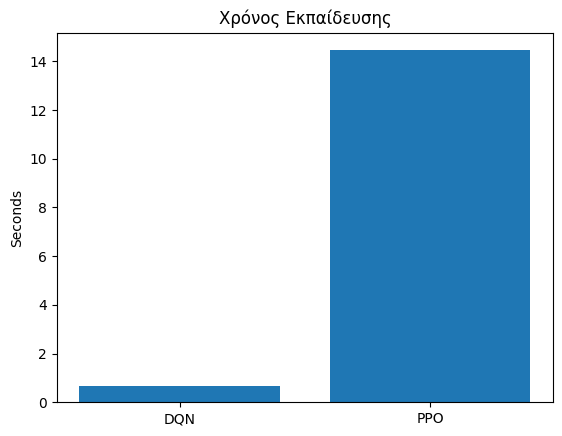

In [ ]:
plt.bar(["DQN", "PPO"], [dqn_training_time, ppo_training_time])
plt.ylabel("Seconds")
plt.title("Training Time")
plt.show()


### Conlcusions
By looking at the graphs the DQN had better results instead of the last episode in which it gets worst. In average DQN is working better than PPO.

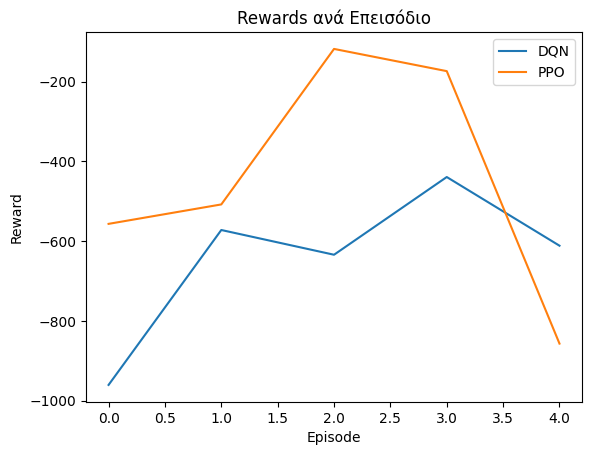

In [ ]:
plt.plot(dqn_scores, label="DQN")
plt.plot(ppo_scores, label="PPO")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per episode")
plt.legend()
plt.show()


# Question 8

Data link:
https://huggingface.co/sb3/dqn-LunarLander-v2


Streaming output truncated to the last 5000 lines.
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 374          |
|    ep_rew_mean          | 121          |
| time/                   |              |
|    fps                  | 169          |
|    iterations           | 740          |
|    time_elapsed         | 4458         |
|    total_timesteps      | 757760       |
| train/                  |              |
|    approx_kl            | 0.0072210208 |
|    clip_fraction        | 0.0818       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.717       |
|    explained_variance   | 0.974        |
|    learning_rate        | 0.0003       |
|    loss                 | 13           |
|    n_updates            | 2956         |
|    policy_gradient_loss | -0.00474     |
|    value_loss           | 32.9         |
------------------------------------------
------------------------------------------
| r

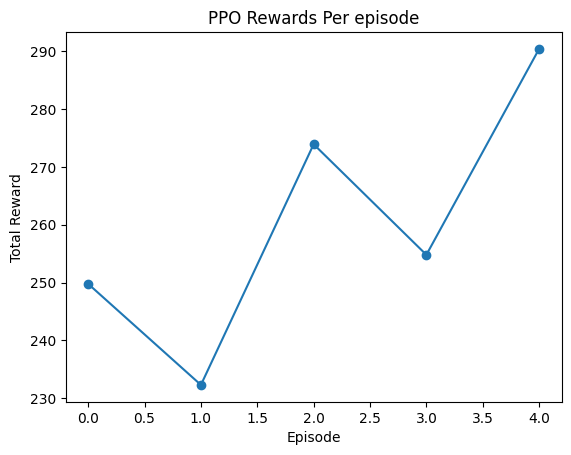

In [14]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.0003,
    n_steps=1024,
    batch_size=64,
    n_epochs=4,
    gamma=0.999,
    gae_lambda=0.98,
    ent_coef=0.01,
    verbose=1
)

# Calculate model training time
start_time = time()
ppo_model.learn(total_timesteps=1_000_000)
ppo_training_time = time() - start_time

# init variables
episodes = 5
ppo_scores = []


for episode in range(episodes):
  observation, info = env.reset()
  sum_reward = 0
  while True :
    # action = env.action_space.sample()
    action, _states = ppo_model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)

    sum_reward = sum_reward + reward

    if terminated or truncated:
      break

  ## Debugg if results are correct
  # print("sum_reward: ",sum_reward)
  # env.play()

  # sum scores
  ppo_scores.append(sum_reward)

# print results
print(f"All scores: {ppo_scores}")
print(f"Average score: {sum(ppo_scores)/len(ppo_scores)}")


plt.plot(ppo_scores, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Rewards Per episode")
plt.show()

# env.play()




Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 108      |
|    ep_rew_mean      | -186     |
|    exploration_rate | 0.968    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 152      |
|    time_elapsed     | 2        |
|    total_timesteps  | 432      |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 1.07     |
|    n_updates        | 428      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 94.1     |
|    ep_rew_mean      | -151     |
|    exploration_rate | 0.944    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 151      |
|    time_elapsed     | 4        |
|    total_timesteps  | 753      |
| train/              |       

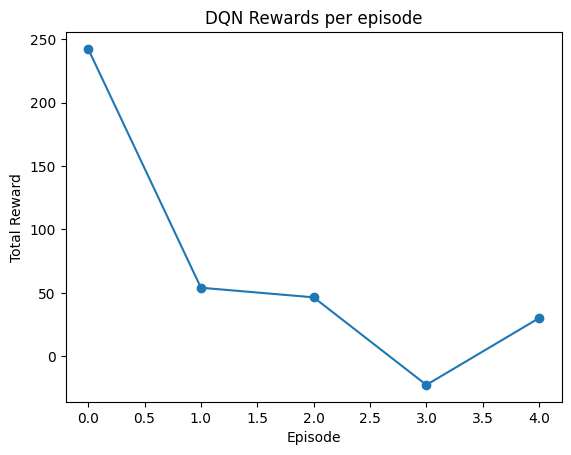

In [13]:
dqn_model = DQN(
    "MlpPolicy",
    env,
    learning_rate=0.00063,
    buffer_size=50000,
    batch_size=128,
    gamma=0.99,
    train_freq=4,
    gradient_steps=-1,
    target_update_interval=250,
    exploration_fraction=0.12,
    exploration_final_eps=0.1,
    learning_starts=0,
    policy_kwargs=dict(net_arch=[256, 256]),
    verbose=1
)

# Calculate model training time
start_time = time()
dqn_model.learn(total_timesteps=100000)
dqn_training_time = time() - start_time

# init variables
episodes = 5
dqn_scores = []


for episode in range(episodes):
  observation, info = env.reset()
  sum_reward = 0
  while True :
    # action = env.action_space.sample()
    action, _states = dqn_model.predict(observation, deterministic=True)
    observation, reward, terminated, truncated, info = env.step(action)

    sum_reward = sum_reward + reward

    if terminated or truncated:
      break

  ## Debugg if results are correct
  # print("sum_reward: ",sum_reward)
  # env.play()

  # sum scores
  dqn_scores.append(sum_reward)

# print results
print(f"All scores: {dqn_scores}")
print(f"Average score: {sum(dqn_scores)/len(dqn_scores)}")


plt.plot(dqn_scores, marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Rewards per episode")
plt.show()

# env.play()




## Final plot for training time

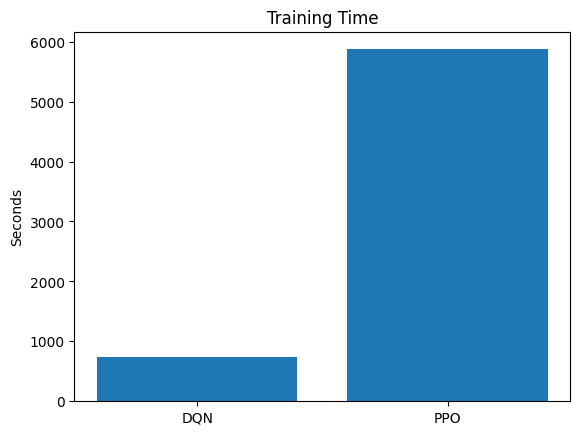

In [15]:
plt.bar(["DQN", "PPO"], [dqn_training_time, ppo_training_time])
plt.ylabel("Seconds")
plt.title("Training Time")
plt.show()


## Final plot for reward per episode

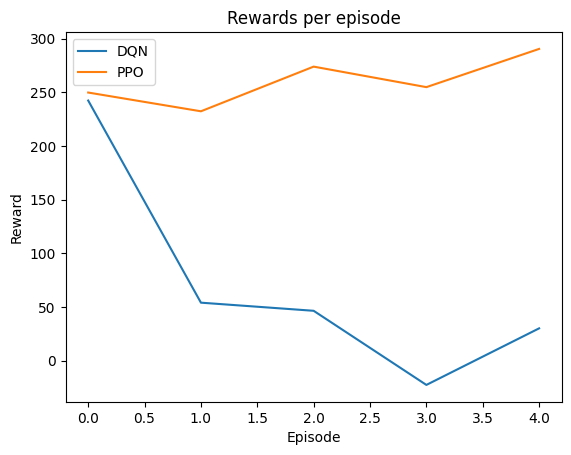

In [16]:
plt.plot(dqn_scores, label="DQN")
plt.plot(ppo_scores, label="PPO")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Rewards per episode")
plt.legend()
plt.show()


# Final answer

The DQN agent is not learning during the episodes. The training is based solely on the call to the learn() method. On the other hand PPO might be very time consuming but it has great performance rather than DQN.